# EDA и разработка токенайзера 

В этом ноутбуке приведен подробный разведочный анализ и предобработка данных, а также все шаги по разработке собственного токенайзера, подходящего для этого датасета. 

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import TweetTokenizer
from string import punctuation
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Загрузка данных и EDA

Для каждого твита указано:
*   UserName - имя пользователя, заменено на целое число для анонимности
*   ScreenName - отображающееся имя пользователя, заменено на целое число для анонимности
*   Location - местоположение
*   TweetAt - дата создания твита
*   OriginalTweet - текст твита
*   Sentiment - эмоциональная окраска твита

In [2]:
df = pd.read_csv('../data/tweets_coronavirus.csv', encoding='latin-1')
df.head()

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,3800,48752,UK,16-03-2020,advice Talk to your neighbours family to excha...,Positive
1,3801,48753,Vagabonds,16-03-2020,Coronavirus Australia: Woolworths to give elde...,Positive
2,3802,48754,NaN,16-03-2020,My food stock is not the only one which is emp...,Positive
3,3803,48755,NaN,16-03-2020,"Me, ready to go at supermarket during the #COV...",Extremely Negative
4,3804,48756,"ÃÂT: 36.319708,-82.363649",16-03-2020,As news of the regionÃÂs first confirmed COV...,Positive


In [3]:
print(f'Количество твитов: {df.shape[0]}')

Количество твитов: 33444


### Анализ целевой переменной

In [4]:
list(df['Sentiment'].unique())

['Positive', 'Extremely Negative', 'Negative', 'Extremely Positive']

Целевая переменная - колонка `Sentiment`. Бинаризуем ее: 
* 1 - 'Positive' и 'Extremely Positive',
* 0 - 'Negative' и 'Extremely Negative'

In [5]:
df['Binary_sentiment'] = df['Sentiment'].apply(lambda x: 1 if x in ['Positive', 'Extremely Positive'] else 0)

In [6]:
count_0 = (df['Binary_sentiment'] == 0).sum()
count_1 = (df['Binary_sentiment'] == 1).sum()
print('Распределение классов:')
print(f"negative: {count_0} ({count_0/len(df)*100:.0f}%)")
print(f"positive: {count_1} ({count_1/len(df)*100:.0f}%)")

Распределение классов:
negative: 15398 (46%)
positive: 18046 (54%)


### Анализ признаков 

In [7]:
print('Пропуски в данных:')
print(df.isnull().sum())

Пропуски в данных:
UserName               0
ScreenName             0
Location            7049
TweetAt                0
OriginalTweet          0
Sentiment              0
Binary_sentiment       0
dtype: int64


Вместо неизвестных местоположений укажем 'Unknown'

In [8]:
df['Location'] = df['Location'].fillna('Unknown')

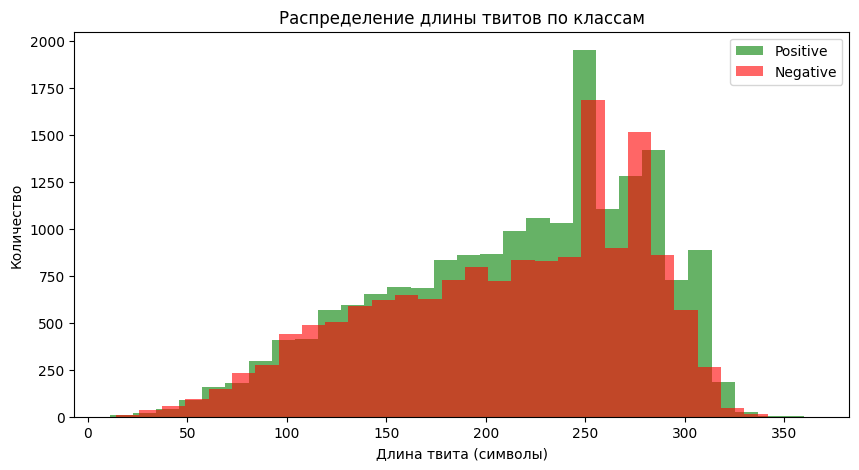

In [9]:
df['tweet_length'] = df['OriginalTweet'].str.len()

plt.figure(figsize=(10, 5))
plt.hist(df[df['Binary_sentiment'] == 1]['tweet_length'], 
         bins=30, alpha=0.6, label='Positive', color='green')
plt.hist(df[df['Binary_sentiment'] == 0]['tweet_length'], 
         bins=30, alpha=0.6, label='Negative', color='red')
plt.xlabel('Длина твита (символы)')
plt.ylabel('Количество')
plt.title('Распределение длины твитов по классам')
plt.legend()
plt.show()

In [13]:
print(f'Средняя длина твитов: {np.mean(df['tweet_length']):.2f} символов')

Средняя длина твитов: 213.14 символов


Проверим, могут ли признаки `UserName`, `ScreenName`, `Location`, `TweetAt` быть полезными для нашей классификации 

In [40]:
print(f"Количество уникальных значений UserName: {df['UserName'].nunique()}")
print(f"Количество уникальных значений ScreenName: {df['ScreenName'].nunique()}")
print(f"Количество уникальных локаций: {df['Location'].nunique()}")
print(f"Количество твитов: {df.shape[0]}")

Количество уникальных значений UserName: 33444
Количество уникальных значений ScreenName: 33444
Количество уникальных локаций: 10465
Количество твитов: 33444


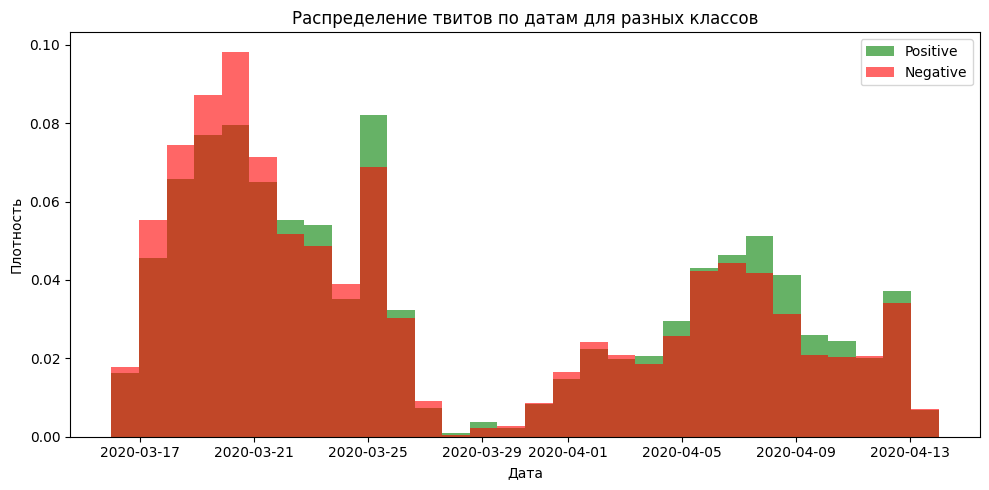

In [29]:
df['TweetAt_clean'] = pd.to_datetime(df['TweetAt'], errors='coerce', dayfirst=True)
positive_dates = df[df['Binary_sentiment'] == 1]['TweetAt_clean']
negative_dates = df[df['Binary_sentiment'] == 0]['TweetAt_clean']

plt.figure(figsize=(10, 5))
plt.hist(positive_dates, bins=30, alpha=0.6, label='Positive', color='green', density=True)
plt.hist(negative_dates, bins=30, alpha=0.6, label='Negative', color='red', density=True)
plt.xlabel('Дата')
plt.ylabel('Плотность')
plt.title('Распределение твитов по датам для разных классов')
plt.legend()
plt.tight_layout()
plt.show()

- Дополнительные признаки `UserName`, `ScreenName` бесполезны для нашей задачи классификации, так как они индивидуальны для каждого твита и не несут информации о тональности.
- Распределение положительных и отрицательных твитов по датам почти одинаковое, и не наблюдается четкой зависимости тональности от времени. 
- Дополнительно изучить признак `Location`, так как он может быть полезен

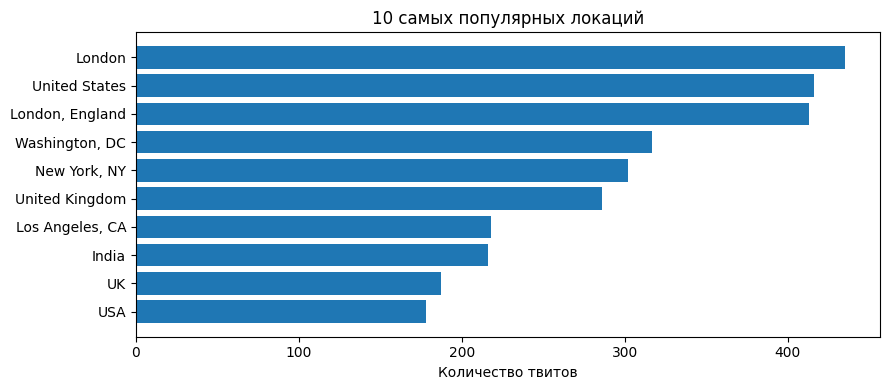

In [41]:
top_locations = df[df['Location'] != 'Unknown']['Location'].value_counts().head(10)

plt.figure(figsize=(9, 4))
plt.barh(top_locations.index, top_locations.values)
plt.xlabel('Количество твитов')
plt.title('10 самых популярных локаций')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Возьмем наиболее широкое местоположение для каждой локации и объединим некоторые названия стран, чтобы снизить число уникальных значений

In [46]:
def get_widerlocation(location):
    if ',' in location:
        parts = [p.strip() for p in location.split(',')]
        wider_loc = parts[-1].strip()
    else:
        wider_loc = location
    wider_loc = wider_loc.strip()
    if wider_loc in ['USA', 'United States', 'United States of America']:
        wider_loc = 'USA'
    elif wider_loc in ['UK', 'England', 'United Kingdom']:
        wider_loc = 'UK'
    return wider_loc

df['WiderLocation'] = df['Location'].apply(get_widerlocation)

print(f"Количество уникальных локаций: {df['Location'].nunique()}")
print(f"Количество уникальных широких локаций: {df['WiderLocation'].nunique()}")

Количество уникальных локаций: 10465
Количество уникальных широких локаций: 6114


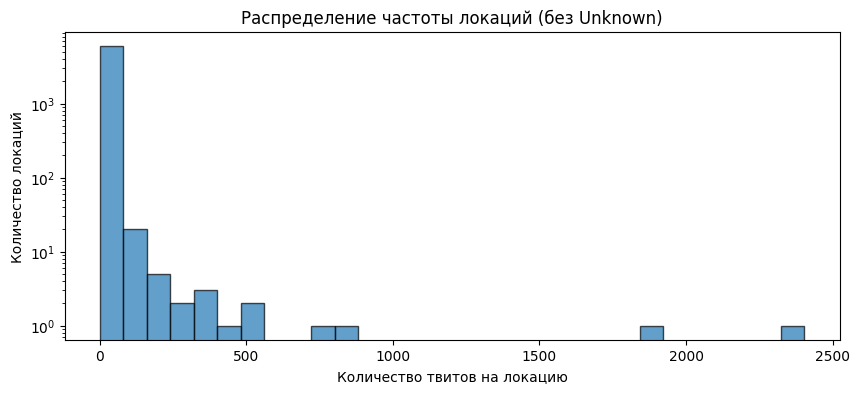

In [47]:
loc_counts = df[df['WiderLocation'] != 'Unknown']['WiderLocation'].value_counts()

plt.figure(figsize=(10, 4))
plt.hist(loc_counts, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Количество твитов на локацию')
plt.ylabel('Количество локаций')
plt.title('Распределение частоты локаций (без Unknown)')
plt.yscale('log')  
plt.show()

In [49]:
print(f"Всего уникальных локаций: {len(loc_counts)}")
print(f"Локаций, встретившихся больше 1 раза: {(loc_counts > 1).sum()}")
print(f"Локаций, встретившихся больше 10 раз: {(loc_counts > 10).sum()}")

Всего уникальных локаций: 6113
Локаций, встретившихся больше 1 раза: 1303
Локаций, встретившихся больше 10 раз: 233


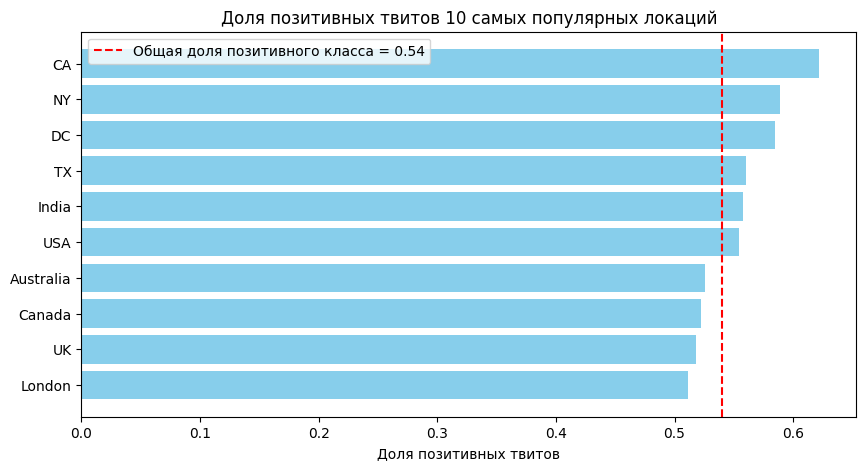

In [50]:
global_pos_ratio = df['Binary_sentiment'].mean()
top_locs = loc_counts.head(10).index
df_top_locs = df[df['WiderLocation'].isin(top_locs)]
pos_ratio_by_loc = df_top_locs.groupby('WiderLocation')['Binary_sentiment'].mean().sort_values()

plt.figure(figsize=(10, 5))
bars = plt.barh(pos_ratio_by_loc.index, pos_ratio_by_loc.values, color='skyblue')
plt.axvline(global_pos_ratio, color='red', linestyle='--', label=f'Общая доля позитивного класса = {global_pos_ratio:.2f}')
plt.xlabel('Доля позитивных твитов')
plt.title('Доля позитивных твитов 10 самых популярных локаций')
plt.legend()
plt.show()

- Большинство локаций встречаются редко (всего 233 локации встречаются в более, чем 10 твитах), что делает их непригодными для обучения модели.
- В топ-10 локаций доля позитивных твитов варьируется от 50% до 60%, что близко к общей доле позитивного класса (54%). Это указывает на отсутствие сильной зависимости тональности от местоположения.
- Дополнительный эксперимент с добавлением OHE-кодированных локаций (проведённый отдельно) не показал прироста качества, поэтому не стоит включать этот признак в классификацию.

# Эксперименты с токенизацией и предобработкой текста

In [ ]:
X = df['OriginalTweet']
y = df['Binary_sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)

## Токенизация по пробелам

In [9]:
all_tokens = []
for tweet in X_train:
    tokens = tweet.lower().split()
    all_tokens.extend(tokens)
token_counts = Counter(all_tokens)
print(f'Размер словаря токенов: {len(token_counts)}')

Размер словаря токенов: 80027


In [10]:
print(f'Топ-10 самых популярных токенов:')
for i, (token, count) in enumerate(token_counts.most_common(10), 1):
    print(f"{i}. '{token}' — {count}")

Топ-10 самых популярных токенов:
1. 'the' — 26708
2. 'to' — 23432
3. 'and' — 14535
4. 'of' — 13123
5. 'a' — 11754
6. 'in' — 11291
7. 'for' — 8571
8. '#coronavirus' — 8222
9. 'is' — 7411
10. 'are' — 7020


В топе в основном встречаются служебные слова (стоп-слова), так как они необходимы для грамматической структуры предложений. Также на 8 месте хештег #coronavirus как общая тема для всех этих твитов

### Удаление стоп-слов

In [11]:
nltk.download("stopwords", quiet=True)
stop_words = stopwords.words('english')

In [12]:
new_all_tokens = []
for token in all_tokens:
    if token not in stop_words:
        new_all_tokens.append(token)

new_token_counts = Counter(new_all_tokens)
print(f'Топ-10 самых популярных токенов:')
for i, (token, count) in enumerate(new_token_counts.most_common(10), 1):
    print(f"{i}. '{token}' — {count}")

Топ-10 самых популярных токенов:
1. '#coronavirus' — 8222
2. 'prices' — 3906
3. 'food' — 3804
4. 'grocery' — 3442
5. 'supermarket' — 3250
6. 'covid-19' — 3188
7. 'store' — 3142
8. 'people' — 3113
9. '#covid19' — 2473
10. 'consumer' — 2288


После удаления стоп-слов в топе осталось 2 хештега и слова, лучше отражающие реальные темы твитов

In [13]:
print(f'Топ-20 самых непопулярных токенов:')
for i, (token, count) in enumerate(new_token_counts.most_common()[:-21:-1], 1):
    print(f"{i}. '{token}' — {count}")

Топ-20 самых непопулярных токенов:
1. 'https://t.co/ndabff1xum' — 1
2. 'despots' — 1
3. 'https://t.co/bqjptcszp7' — 1
4. 'have)' — 1
5. 'virus!(please' — 1
6. 'fluid,' — 1
7. 'pc).' — 1
8. 'boxes(50' — 1
9. 'layers.' — 1
10. 'hmm..' — 1
11. 'https://t.co/yruvb9tw5m' — 1
12. 'spinach...' — 1
13. 'kale' — 1
14. 'empathise' — 1
15. 'https://t.co/0evoznirqx' — 1
16. 'https://t.co/eoy2aggxuc' — 1
17. 'share?' — 1
18. 'testimonial' — 1
19. 'feature,' — 1
20. 'coronavirus".' — 1


Эти токены самые непопулярные, потому что содержат уникальные ссылки на твиты, слова с прилипшей пунктуацией (не разделились простой токенизацией) и специфические слова, которые редко используются

## TweetTokenizer

In [14]:
tw_tokenizer = TweetTokenizer()
tw_tokens = []
for tweet in X_train:
    tokens = tw_tokenizer.tokenize(tweet)
    tw_tokens.extend(tokens)

In [15]:
tw_token_counts = Counter(tw_tokens)
print(f'Топ-10 самых популярных токенов:')
for i, (token, count) in enumerate(tw_token_counts.most_common(10), 1):
    print(f"{i}. '{token}' — {count}")

Топ-10 самых популярных токенов:
1. 'the' — 24320
2. '.' — 23953
3. 'to' — 22998
4. ',' — 17620
5. 'and' — 14199
6. 'of' — 13022
7. 'a' — 11090
8. 'in' — 10663
9. '?' — 9525
10. 'for' — 8250


В отличие от простого split, tweettokenizer сохраняет знаки пунктуации как отдельные токены, поэтому топ состоит из них и стоп-слов. Знаки тоже сохраняются, так как в контексте твитов они тоже могут нести эмоциональную окраску

### Удаление стоп-слов и пунктуации

In [16]:
noise = stopwords.words("english") + list(punctuation)

In [17]:
no_noise_tw_tokens = []
for tweet in X_train:
    tokens = tw_tokenizer.tokenize(tweet)
    tokens = [token.lower() for token in tokens if token.lower() not in noise]
    no_noise_tw_tokens.extend(tokens)

no_noise_tw_counts = Counter(no_noise_tw_tokens)
print(f'Топ-10 самых популярных токенов:')
for i, (token, count) in enumerate(no_noise_tw_counts.most_common(10), 1):
    print(f"{i}. '{token}' — {count}")

Топ-10 самых популярных токенов:
1. '#coronavirus' — 8795
2. 'â' — 7319
3. '' — 7222
4. '19' — 7180
5. 'covid' — 6237
6. 'prices' — 4599
7. 'food' — 4362
8. '' — 4315
9. 'store' — 3868
10. 'supermarket' — 3797


Теперь в топе есть 3 непонятных символа, которые появились из-за проблем с кодировкой, а также число 19, которое не несет эмоциональной окраски. Остальные токены соответствуют теме твитов

### Удаление артефактов кодировки

In [18]:
no_art_tw_tokens = []
for tweet in X_train:
    tokens = tw_tokenizer.tokenize(tweet)
    tokens = [token.lower() for token in tokens if token.lower() not in noise and not (len(token) == 1 and ord(token.lower()) >= 128) and not token.isdigit()]
    no_art_tw_tokens.extend(tokens)

no_art_tw_counts = Counter(no_art_tw_tokens)
print(f'Топ-10 самых популярных токенов:')
for i, (token, count) in enumerate(no_art_tw_counts.most_common(10), 1):
    print(f"{i}. '{token}' — {count}")

Топ-10 самых популярных токенов:
1. '#coronavirus' — 8795
2. 'covid' — 6237
3. 'prices' — 4599
4. 'food' — 4362
5. 'store' — 3868
6. 'supermarket' — 3797
7. 'grocery' — 3501
8. 'people' — 3396
9. '#covid19' — 2582
10. 'consumer' — 2381


In [19]:
print('Топ-20 самых непопулярных токенов:')
for i, (token, count) in enumerate(no_art_tw_counts.most_common()[:-21:-1], 1):
    print(f"{i}. '{token}' — {count}")

Топ-20 самых непопулярных токенов:
1. 'https://t.co/ndabff1xum' — 1
2. 'despots' — 1
3. 'https://t.co/bqjptcszp7' — 1
4. 'https://t.co/yruvb9tw5m' — 1
5. 'empathise' — 1
6. 'https://t.co/0evoznirqx' — 1
7. 'https://t.co/eoy2aggxuc' — 1
8. 'testimonial' — 1
9. 'https://t.co/oyc05zegcu' — 1
10. 'zambia' — 1
11. 'https://t.co/npn4ftknid' — 1
12. 'https://t.co/a04ysm1f9h' — 1
13. 'https://t.co/opnigtt6zt' — 1
14. 'https://t.co/gp65snkbiw' — 1
15. 'overreactionã' — 1
16. 'perceive' — 1
17. 'blocker' — 1
18. '@worldometer' — 1
19. 'https://t.co/ykwbgw7a3m' — 1
20. 'epra' — 1


Из топа самых популярных слов пропали артефакты кодировки, одиночные числа, стоп-слова и знаки пунктуации, самые частые токены стали содержательными.

Из топа самых непопулярных слов исчезли слова с прилипшей пунктуацией, и теперь он состоит из уникальных ссылок, редких слов, а также упоминания пользователя (@worldometer).

## Анализ хештегов и ссылок

In [27]:
hashtags = []
for tweet in X_train:
    tokens = tw_tokenizer.tokenize(tweet)
    tokens = [token.lower() for token in tokens if token.startswith('#')]
    hashtags.extend(tokens)

hashtags_counts = Counter(hashtags)
print('Топ-10 самых популярных хештегов:')
for i, (token, count) in enumerate(hashtags_counts.most_common(10), 1):
    print(f"{i}. '{token}' — {count}")

Топ-10 самых популярных хештегов:
1. '#coronavirus' — 8795
2. '#covid19' — 2582
3. '#covid_19' — 1768
4. '#covid2019' — 950
5. '#toiletpaper' — 765
6. '#covid' — 658
7. '#socialdistancing' — 484
8. '#coronacrisis' — 431
9. '#coronaviruspandemic' — 249
10. '#pandemic' — 239


Все хэштеги в основном похожи между собой и представляют разные варианты написания "covid19", но при этом есть и содержательные (#toiletpaper, #socialdistancing)

In [28]:
links = []
for tweet in X_train:
    tokens = tw_tokenizer.tokenize(tweet)
    tokens = [token.lower() for token in tokens if token.lower().startswith('https://t.co')]
    links.extend(tokens)

links_counts = Counter(links)
print('Топ-10 самых популярных ссылок:')
for i, (token, count) in enumerate(links_counts.most_common(10), 1):
    print(f"{i}. '{token}' — {count}")

Топ-10 самых популярных ссылок:
1. 'https://t.co/oxa7swtond' — 6
2. 'https://t.co/3kfuiojxep' — 4
3. 'https://t.co/ymsemlvttd' — 4
4. 'https://t.co/r7sagojsjg' — 4
5. 'https://t.co/wrlhyzizaa' — 4
6. 'https://t.co/3gbbdpdjat' — 3
7. 'https://t.co/catkegayoy' — 3
8. 'https://t.co/bylqxrjmnt' — 3
9. 'https://t.co/e2znxajpre' — 3
10. 'https://t.co/mlw1gfkzna' — 3


Популярность ссылок не сравнима с популярностью хештегов (самая популярная ссылка встречается 6 раз, самый популярный токен с хештегом #coronavirus — 8795 раз). Можем сделать вывод, что информация о ссылках на конкретные страницы не будет полезной, так как каждая ссылка уникальная и используется крайне редко, а также они не несут никакой информации об эмоциональной окраске твита.

# Собственный токенайзер

На основе проведенных экспериментов теперь можем написать собственную функцию токенайзера для улучшения TweetTokenizer, которая должна:
- Приводить текст в нижний регистр,
- Применять TweetTokenizer для выделения токенов,
- Удалять:
  - Стоп-слова, 
  - Пунктуацию, 
  - Одиночные символы с позицией в таблице Unicode 128 и более (артефакты кодировки), 
  - Отдельно стоящие числа (не в составе слов как в '#covid19') 
  - Ссылки на t.co

Код функции улучшенного токенайзера приведен в файле `src/tokenizers.py`

In [ ]:
import sys
import os
current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.insert(0, project_root)

from src.tokenizers import custom_tokenizer

In [23]:
all_custom_tokens = []
for text in X_train:
    all_custom_tokens.extend(custom_tokenizer(text))
print(f'Размер словаря улучшенного TweetTokenizer: {len(set(all_custom_tokens))}')

Размер словаря улучшенного TweetTokenizer: 45083


In [29]:
custom_counts = Counter(all_custom_tokens)
print('Топ-10 самых популярных токенов:')
for i, (token, count) in enumerate(custom_counts.most_common(10), 1):
    print(f"{i}. '{token}' — {count}")

Топ-10 самых популярных токенов:
1. '#coronavirus' — 8795
2. 'covid' — 6237
3. 'prices' — 4599
4. 'food' — 4362
5. 'store' — 3868
6. 'supermarket' — 3797
7. 'grocery' — 3501
8. 'people' — 3396
9. '#covid19' — 2582
10. 'consumer' — 2381


In [30]:
print('Топ-20 самых непопулярных токенов:')
for i, (token, count) in enumerate(custom_counts.most_common()[:-21:-1], 1):
    print(f"{i}. '{token}' — {count}")

Топ-20 самых непопулярных токенов:
1. 'despots' — 1
2. 'empathise' — 1
3. 'testimonial' — 1
4. 'zambia' — 1
5. 'overreactionã' — 1
6. 'perceive' — 1
7. 'blocker' — 1
8. '@worldometer' — 1
9. 'epra' — 1
10. '#nijobs' — 1
11. '#asksuzy' — 1
12. 'category-specific' — 1
13. 'suzy' — 1
14. 'suffices' — 1
15. 'shithouses' — 1
16. 'soc' — 1
17. '400k' — 1
18. 'supply-side' — 1
19. 'cigarette-maker' — 1
20. '50-80' — 1


**Выводы**: 
- Размер словаря уменьшился почти в 2 раза (с 80027 до 45083),
- По преведенным выше топам заметно, что из словаря исчезли все токены, не несущие информации об эмоциональной окраске твита,

Разработанный токенайзер отлично справился с задачей и может быть использован в дальнейшей работе